In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Proiect_Licenta_XAUUSD'


df = pd.read_csv(f"{PROJECT_PATH}/data/processed/XAUUSD_with_indicators.csv", index_col=0, parse_dates=True)

prediction_horizon = 3
df['target'] = np.log(df['close'].shift(-prediction_horizon) / df['close'])
df = df.dropna()

features = [
    'dist_ema_200', 'atr', 'bb_pct', 'fix_vix', 'is_vix_green', 
    'smi_oversold', 'smi_overbought', 'ret_1h', 'ret_3h', 'hour', 'day_of_week'
]
smi_col = [c for c in df.columns if 'smi' in c and 'over' not in c and '_s' not in c][0]
features.append(smi_col)

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_x.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[['target']])

print("Data has been scaled between 0 and 1")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data has been scaled between 0 and 1


In [2]:
profit_threshold = 0.001 

y_class = (df['target'] > profit_threshold).astype(int)

print(f"Class distribution after applying profit threshold:\n{y_class.value_counts()}")

scaler_x = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_x.fit_transform(df[features])

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 48
X_seq, y_seq = create_sequences(X_scaled, y_class.values, time_steps)

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"New training data shape: {X_train.shape}")

Class distribution after applying profit threshold:
target
0    82760
1    41925
Name: count, dtype: int64
New training data shape: (99709, 48, 12)


In [ ]:
model_lstm_advanced = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    
    Dense(16, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

model_lstm_advanced.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

history = model_lstm_advanced.fit(
    X_train, y_train,
    epochs=30, 
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
 317/1558 ━━━━━━━━━━━━━━━━━━━━ 1:49 88ms/step - accuracy: 0.6576 - loss: 0.6431

In [ ]:
model_save_path = os.path.join(PROJECT_PATH, 'models', 'lstm_advanced_v1.keras')
scaler_x_path = os.path.join(PROJECT_PATH, 'models', 'scaler_x.pkl')

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

model_lstm_advanced.save(model_save_path)

joblib.dump(scaler_x, scaler_x_path)

print(f" LSTM model saved to: {model_save_path}")

780/780 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


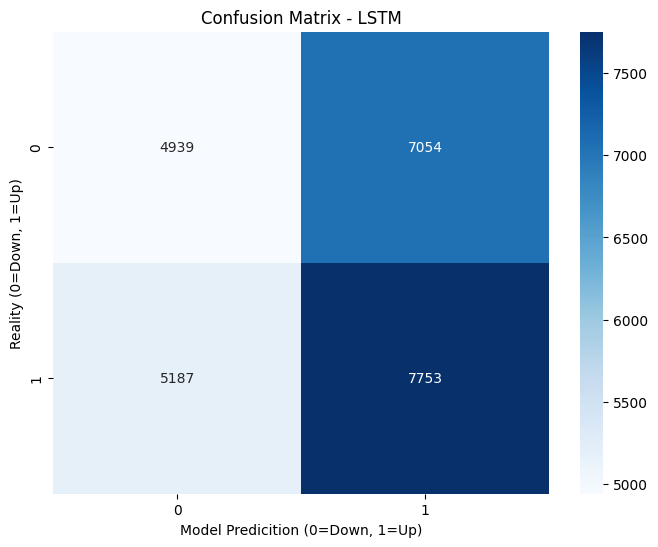

              precision    recall  f1-score   support

           0       0.49      0.41      0.45     11993
           1       0.52      0.60      0.56     12940

    accuracy                           0.51     24933
   macro avg       0.51      0.51      0.50     24933
weighted avg       0.51      0.51      0.50     24933



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model_lstm_advanced.predict(X_test)

confidence_threshold = 0.60 

high_confidence_signals = (y_pred_probs > confidence_threshold).astype(int).flatten()
y_test_flat = y_test.flatten()

trades_taken = np.sum(high_confidence_signals)
winning_trades = np.sum((high_confidence_signals == 1) & (y_test_flat == 1))

if trades_taken > 0:
    actual_win_rate = winning_trades / trades_taken
    print("Trading Performance")
    print(f"Total high-confidence trades executed: {trades_taken}")
    print(f"Winning trades: {winning_trades}")
    print(f"Actual Win Rate: {actual_win_rate:.2%}")
else:
    print("Confidence threshold is too high. The model found 0 safe trades.")

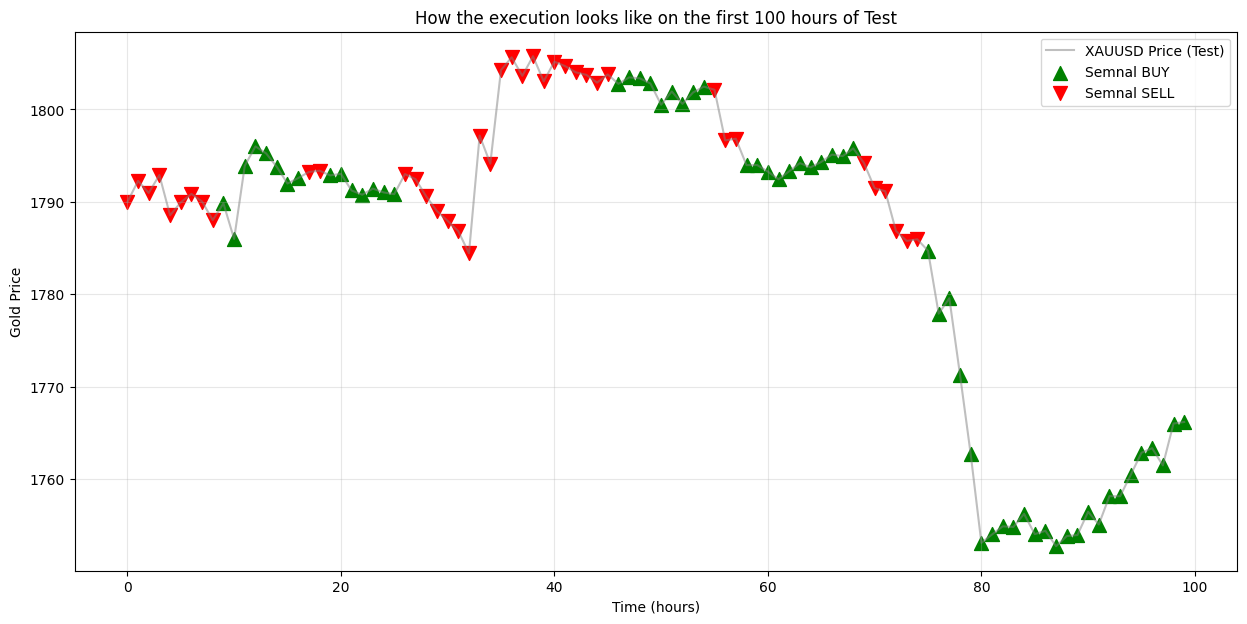

In [5]:

test_prices = df['close'].iloc[split + time_steps:].values

plt.figure(figsize=(15, 7))
plt.plot(test_prices[:100], label='XAUUSD Price (Test)', color='gray', alpha=0.5)


buy_signals = np.where(y_pred_classes[:100] == 1)[0]
plt.scatter(buy_signals, test_prices[buy_signals], marker='^', color='green', label='Semnal BUY', s=100)


sell_signals = np.where(y_pred_classes[:100] == 0)[0]
plt.scatter(sell_signals, test_prices[sell_signals], marker='v', color='red', label='Semnal SELL', s=100)

plt.title('How the execution looks like on the first 100 hours of Test')
plt.xlabel('Time (hours)')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()